# EMPRES-i Basic EDA

Self-contained first-pass EDA for HPAI records in `data/structured/empres_i/overview-raw-data_202605211615.csv`. This notebook follows the same structure as the WAHIS and ADIS EDA notebooks while keeping EMPRES-i-specific host, diagnosis source/status, and human impact fields.


## Setup

Shared plotting, display, and helper functions used throughout the notebook.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

plt.style.use("ggplot")

params = {
    "text.color": (0.25, 0.25, 0.25),
    "figure.figsize": [16, 9],
}

plt.rcParams.update(params)

# Get colors from default theme.
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

import seaborn as sns
# sns.set()


from pathlib import Path

import pandas as pd


pd.options.display.max_columns = 120
pd.options.mode.chained_assignment = None
pd.options.display.max_rows = 500
pd.options.display.max_seq_items = 500

NA_VALUES = ["NaN", "nan", "", ";"]


def find_data_path(*candidates: str) -> Path:
    paths = [Path(candidate) for candidate in candidates]
    path = next((candidate for candidate in paths if candidate.exists()), None)
    if path is None:
        tried = "\n".join(str(candidate) for candidate in paths)
        raise FileNotFoundError(f"Could not find source CSV. Tried:\n{tried}")
    return path


def schema_summary(data: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing": data.isna().sum(),
            "missing_pct": data.isna().mean().mul(100).round(1),
            "n_unique": data.nunique(dropna=True),
        }
    ).sort_values(["missing_pct", "n_unique"], ascending=[False, False])


def top_counts(data: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    return (
        data[column]
        .fillna("Missing")
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(column)
        .reset_index(name="records")
    )


def plot_top_counts(
    data: pd.DataFrame, specs: list[tuple[str, int, str]], cols: int = 2
) -> None:
    rows = -(-len(specs) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 4.8 * rows), squeeze=False)
    for axis, (column, n, title) in zip(axes.ravel(), specs):
        counts = top_counts(data, column, n=n)
        sns.barplot(data=counts, y=column, x="records", ax=axis, color="#4C78A8")
        axis.set_title(title)
        axis.set_xlabel("Records")
        axis.set_ylabel("")
    for axis in axes.ravel()[len(specs) :]:
        axis.set_visible(False)
    plt.tight_layout()


def date_coverage(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "date_column": columns,
            "min_date": [data[column].min() for column in columns],
            "max_date": [data[column].max() for column in columns],
            "missing": [data[column].isna().sum() for column in columns],
            "missing_pct": [
                round(data[column].isna().mean() * 100, 1) for column in columns
            ],
        }
    )


def monthly_counts(
    data: pd.DataFrame, date_column: str, label: str = "records"
) -> pd.DataFrame:
    return (
        data.dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby("month")
        .size()
        .rename(label)
        .reset_index()
    )


def monthly_counts_by_category(
    data: pd.DataFrame,
    date_column: str,
    category_column: str,
    top_n: int = 6,
    label: str = "records",
) -> pd.DataFrame:
    top_values = top_counts(data, category_column, n=top_n)[category_column]
    return (
        data[data[category_column].isin(top_values)]
        .dropna(subset=[date_column])
        .assign(
            month=lambda frame: frame[date_column].dt.to_period("M").dt.to_timestamp()
        )
        .groupby(["month", category_column])
        .size()
        .rename(label)
        .reset_index()
    )


def country_disease_matrix(
    data: pd.DataFrame,
    country_column: str,
    disease_column: str,
    country_n: int = 12,
    disease_n: int = 8,
) -> pd.DataFrame:
    top_countries = top_counts(data, country_column, n=country_n)[country_column]
    top_diseases = top_counts(data, disease_column, n=disease_n)[disease_column]
    filtered = data[
        data[country_column].isin(top_countries)
        & data[disease_column].isin(top_diseases)
    ]
    return pd.crosstab(filtered[country_column], filtered[disease_column])

import contextily as cx
import geopandas as gpd

BASEMAP_SOURCE = cx.providers.CartoDB.Positron


def plot_event_map(
    data: pd.DataFrame,
    longitude_column: str,
    latitude_column: str,
    color_column: str,
    title: str,
    sample_n: int | None = None,
    marker_size: float = 18,
    alpha: float = 0.65,
) -> gpd.GeoDataFrame:
    geo_data = data.dropna(subset=[longitude_column, latitude_column]).copy()
    if sample_n is not None and len(geo_data) > sample_n:
        geo_data = geo_data.sample(sample_n, random_state=42)

    gdf = gpd.GeoDataFrame(
        geo_data,
        geometry=gpd.points_from_xy(geo_data[longitude_column], geo_data[latitude_column]),
        crs='EPSG:4326',
    ).to_crs(epsg=3857)

    fig, axis = plt.subplots(figsize=(11, 9))
    gdf.plot(
        ax=axis,
        column=color_column,
        categorical=True,
        legend=True,
        markersize=marker_size,
        alpha=alpha,
        linewidth=0,
    )
    cx.add_basemap(axis, source=BASEMAP_SOURCE, attribution_size=7)
    axis.set_title(title)
    axis.set_axis_off()
    plt.tight_layout()
    return gdf


## Load Data

EMPRES-i uses semicolon-delimited CSV exports, decimal commas for coordinate fields, and `dd/mm/yyyy` dates.


In [2]:
DATA_PATH = find_data_path(
    "../data/structured/empres_i/overview-raw-data_202605211615.csv",
    "data/structured/empres_i/overview-raw-data_202605211615.csv",
)

raw_df = pd.read_csv(
    DATA_PATH,
    sep=";",
    quotechar='"',
    decimal=",",
    na_values=NA_VALUES,
    keep_default_na=True,
    low_memory=False,
)

print(f"Loaded {len(raw_df):,} rows and {raw_df.shape[1]:,} columns from {DATA_PATH}")
raw_df.head()

Loaded 87,206 rows and 17 columns from ../data/structured/empres_i/overview-raw-data_202605211615.csv


,Event.ID,Disease,Serotype,Region,Subregion,Country,Admin.level.1,Latitude,Longitude,Diagnosis.source,Diagnosis.status,Animal.type,Species,Observation.date..dd.mm.yyyy.,Report.date..dd.mm.yyyy.,Humans.affected,Human.deaths;
0,47130-89yd7,Influenza - Avian,H5N1 HPAI,Europe,Western Europe,Austria,Burgenland,48.048375,16.680534,WOAH (former OIE),Confirmed,Wild - Saker falcon (Falco cherrug),Wild - Saker Falcon (Falco Cherrug),20/05/2026,20/05/2026,NaN,NaN
1,47094-qp9r8,African swine fever,NaN,Europe,Eastern Europe,Ukraine,NaN,49.755448,33.319072,WOAH (former OIE),Confirmed,Domestic - Swine,Domestic - Swine,19/05/2026,19/05/2026,NaN,NaN
2,47258-nr5os,African swine fever,NaN,Europe,Western Europe,Germany,Nordrhein-Westfalen,51.135571,8.299455,WOAH (former OIE),Confirmed,Wild - Wild boar:Sus scrofa(Suidae),Wild - Wild Boar:sus Scrofa(Suidae),18/05/2026,20/05/2026,NaN,NaN
3,47265-zj9vv,African swine fever,NaN,Europe,Western Europe,Germany,Nordrhein-Westfalen,51.123153,8.312165,WOAH (former OIE),Confirmed,Wild - Wild boar:Sus scrofa(Suidae),Wild - Wild Boar:sus Scrofa(Suidae),18/05/2026,20/05/2026,NaN,NaN
4,47097-ygz1o,African swine fever,NaN,Europe,Northern Europe,Latvia,NaN,56.563254,22.755252,WOAH (former OIE),Confirmed,Wild - Wild boar:Sus scrofa(Suidae),Wild - Wild Boar:sus Scrofa(Suidae),17/05/2026,20/05/2026,NaN,NaN


## Clean Working Copy

Strip the trailing semicolon from `Human.deaths;`, filter to HPAI avian influenza records, parse dates/numeric fields, and add report delay metrics.


In [3]:
df = raw_df.copy()
df.columns = df.columns.str.strip().str.rstrip(";")

avian_influenza_mask = (
    df["Disease"]
    .fillna("")
    .str.contains("avian influenza|influenza - avian", case=False, regex=True)
)
hpai_mask = avian_influenza_mask & df["Serotype"].fillna("").str.contains(
    "HPAI|high pathogenic|high pathogenicity",
    case=False,
    regex=True,
)

df = df.loc[hpai_mask].copy()
print(
    f"Filtered to {len(df):,} HPAI records from {len(raw_df):,} total EMPRES-i records."
)

DATE_COLUMNS = [
    "Observation.date..dd.mm.yyyy.",
    "Report.date..dd.mm.yyyy.",
]
for column in DATE_COLUMNS:
    df[column] = pd.to_datetime(df[column], format="%d/%m/%Y", errors="coerce")

NUMERIC_COLUMNS = ["Latitude", "Longitude", "Humans.affected", "Human.deaths"]
for column in NUMERIC_COLUMNS:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["report_delay_days"] = (
    df["Report.date..dd.mm.yyyy."] - df["Observation.date..dd.mm.yyyy."]
).dt.days

duplicate_summary = pd.Series(
    {
        "duplicate_event_id": df["Event.ID"].duplicated().sum(),
    }
)

display(df.dtypes.to_frame("dtype"))
display(duplicate_summary.to_frame("count"))

Filtered to 24,913 HPAI records from 87,206 total EMPRES-i records.


,dtype
Event.ID,str
Disease,str
Serotype,str
Region,str
Subregion,str
Country,str
Admin.level.1,str
Latitude,float64
Longitude,float64
Diagnosis.source,str


,count
duplicate_event_id,0


## Dataset Overview And Completeness


In [4]:
overview = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "countries": [df["Country"].nunique()],
        "diseases": [df["Disease"].nunique()],
        "serotypes": [df["Serotype"].nunique()],
        "animal_types": [df["Animal.type"].nunique()],
        "first_observation_date": [df["Observation.date..dd.mm.yyyy."].min()],
        "last_observation_date": [df["Observation.date..dd.mm.yyyy."].max()],
    }
)

display(overview)
display(schema_summary(df))
display(date_coverage(df, DATE_COLUMNS))

,rows,columns,countries,diseases,serotypes,animal_types,first_observation_date,last_observation_date
0,24913,18,46,1,14,920,2004-05-12,2026-05-20


,dtype,missing,missing_pct,n_unique
Humans.affected,float64,24907,100.0,3
Human.deaths,float64,24913,100.0,0
Admin.level.1,str,540,2.2,560
Observation.date..dd.mm.yyyy.,datetime64[us],92,0.4,2646
report_delay_days,float64,92,0.4,262
Event.ID,str,0,0.0,24913
Latitude,float64,0,0.0,24913
Longitude,float64,0,0.0,24913
Report.date..dd.mm.yyyy.,datetime64[us],0,0.0,1949
Animal.type,str,6,0.0,920


,date_column,min_date,max_date,missing,missing_pct
0,Observation.date..dd.mm.yyyy.,2004-05-12,2026-05-20,92,0.4
1,Report.date..dd.mm.yyyy.,2004-05-12,2026-05-20,0,0.0


## Top Categories


In [5]:
CATEGORY_COLUMNS = [
    "Disease",
    "Serotype",
    "Country",
    "Subregion",
    "Diagnosis.source",
    "Diagnosis.status",
    "Animal.type",
]

for column in CATEGORY_COLUMNS:
    display(top_counts(df, column, n=20))

,Disease,records
0,Influenza - Avian,24913


,Serotype,records
0,H5N1 HPAI,19178
1,H5N8 HPAI,4714
2,H5 HPAI,435
3,H5N5 HPAI,227
4,HPAI,148
5,H5N6 HPAI,96
6,H5N2 HPAI,43
7,H5N9 HPAI,28
8,H7N7 HPAI,15
9,H5N3 HPAI,14


,Country,records
0,Germany,7095
1,France,3044
2,the United Kingdom of Great Britain and Northe...,2152
3,Hungary,1648
4,Netherlands (Kingdom of the),1455
5,Poland,1299
6,Italy,958
7,Denmark,866
8,Russian Federation,842
9,Belgium,738


,Subregion,records
0,Western Europe,13036
1,Eastern Europe,5360
2,Northern Europe,4614
3,Southern Europe,1903


,Diagnosis.source,records
0,WOAH (former OIE),23569
1,National authorities,985
2,International reference laboratory,121
3,Media,93
4,Other,72
5,EC,49
6,FAO officer,18
7,FAO Field Officer,4
8,WHO,2


,Diagnosis.status,records
0,Confirmed,24741
1,Suspected,131
2,Denied,41


,Animal.type,records
0,Domestic - Unspecified bird,5395
1,Wild - Mute Swan:Cygnus olor(Anatidae),1615
2,Wild - Anatidae (incognita),1422
3,Domestic - Duck,1106
4,Wild - Gruidae (unidentified):Gruidae (incogni...,1073
5,Wild - Black headed gull (Chroicocephalus ridi...,891
6,Wild - Greylag Goose:Anser anser(Anatidae),795
7,Domestic - Chicken,560
8,Wild - Anatidae (unidentified):Anatidae (incog...,522
9,Wild - Laridae (unidentified):Laridae (incogni...,494


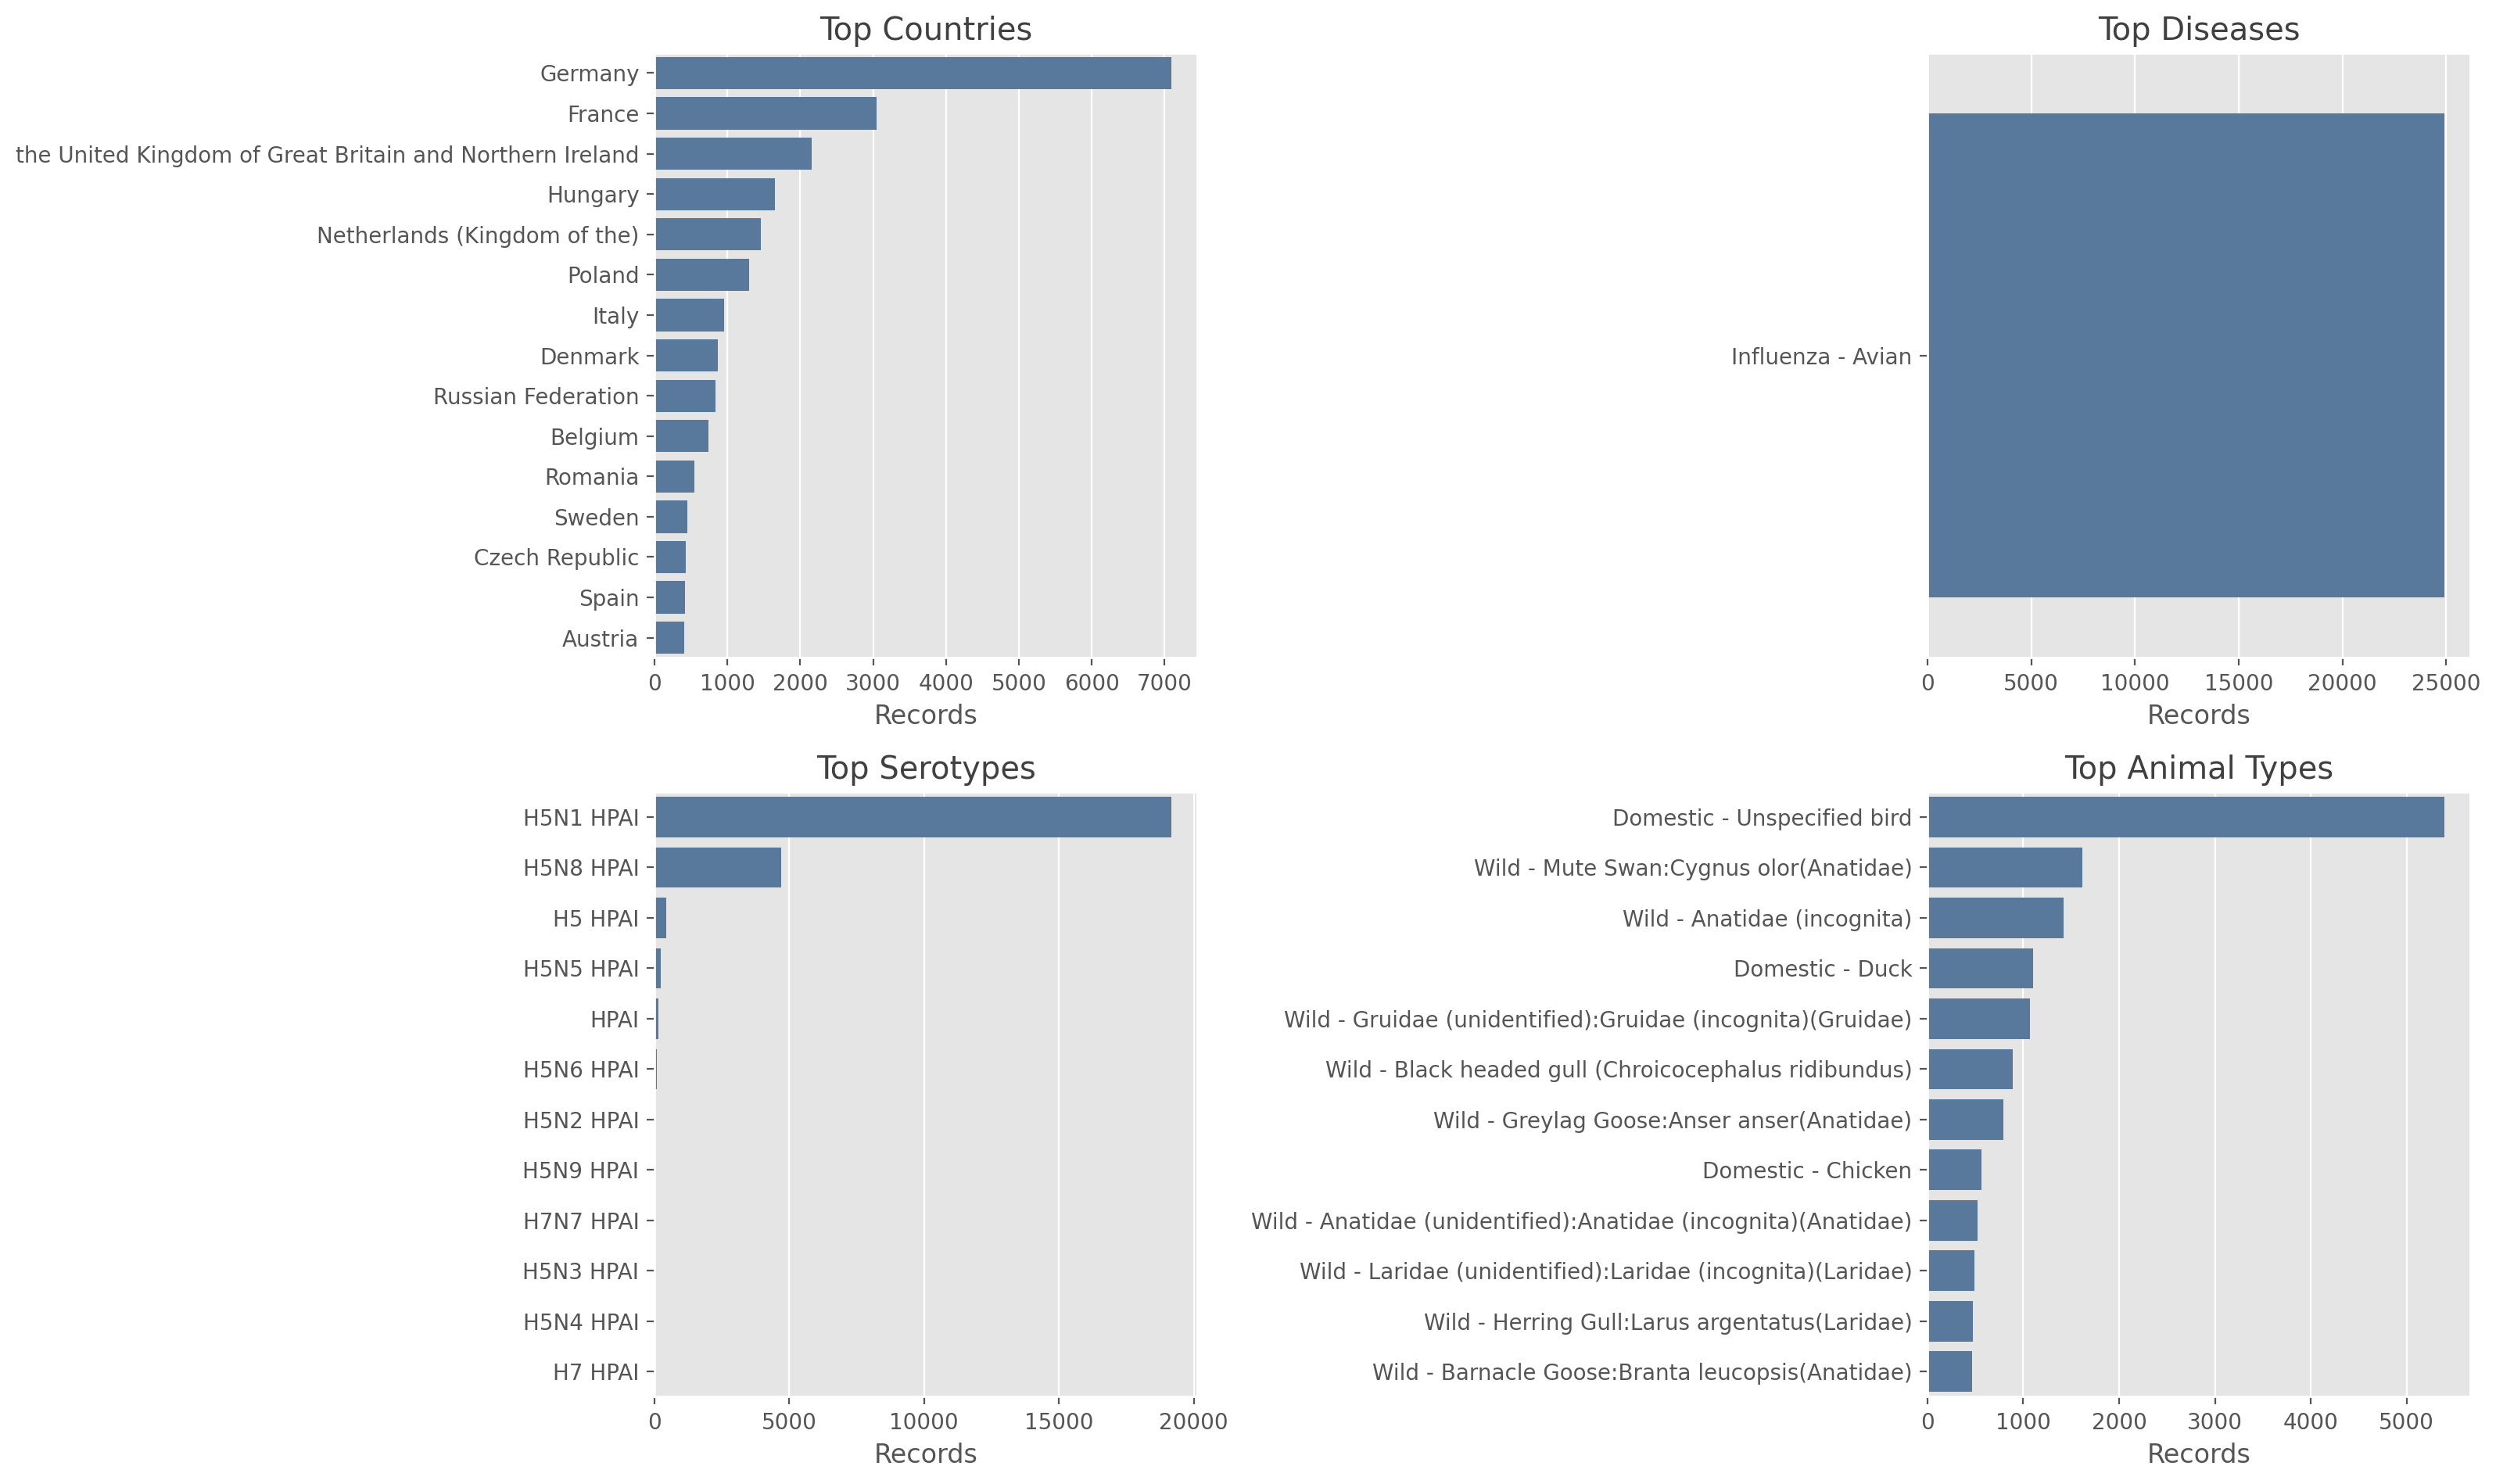

In [6]:
plot_top_counts(
    df,
    [
        ("Country", 15, "Top Countries"),
        ("Disease", 8, "Top Diseases"),
        ("Serotype", 12, "Top Serotypes"),
        ("Animal.type", 12, "Top Animal Types"),
    ],
)

## Time Coverage And Trends


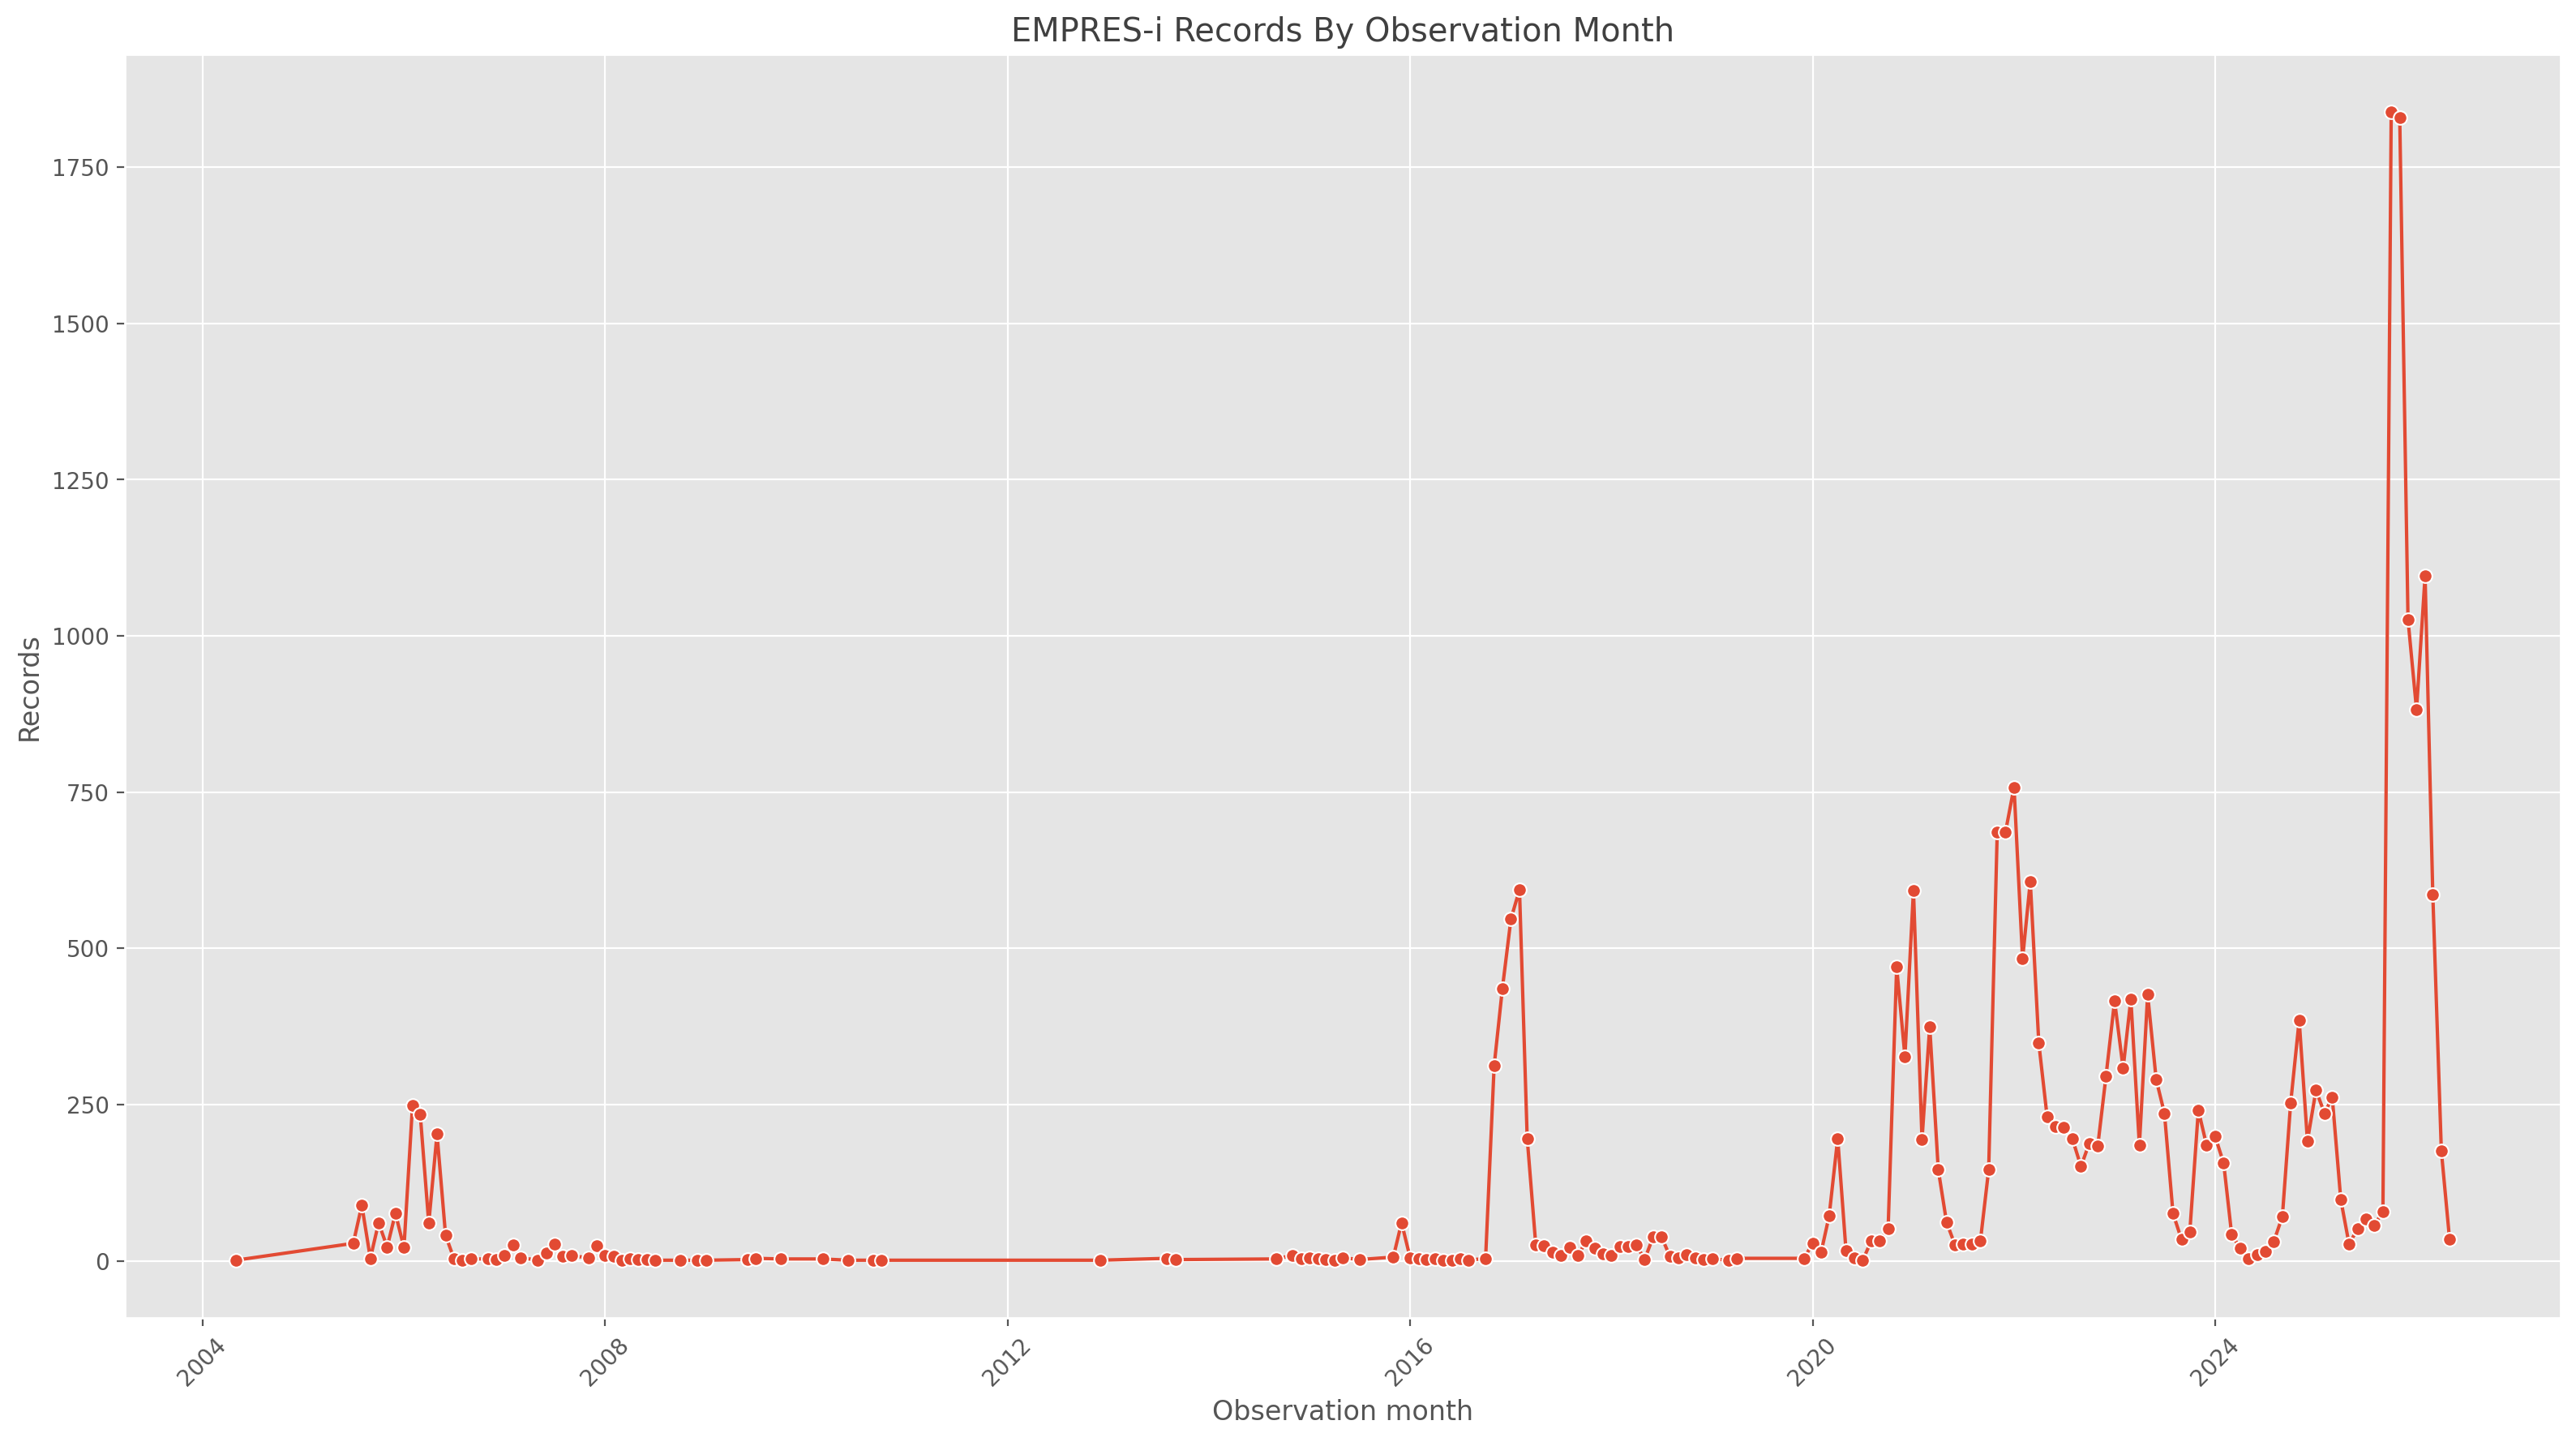

In [7]:
events_by_month = monthly_counts(df, "Observation.date..dd.mm.yyyy.")

sns.lineplot(data=events_by_month, x="month", y="records", marker="o")
plt.title("EMPRES-i Records By Observation Month")
plt.xlabel("Observation month")
plt.ylabel("Records")
plt.xticks(rotation=45)
plt.tight_layout()

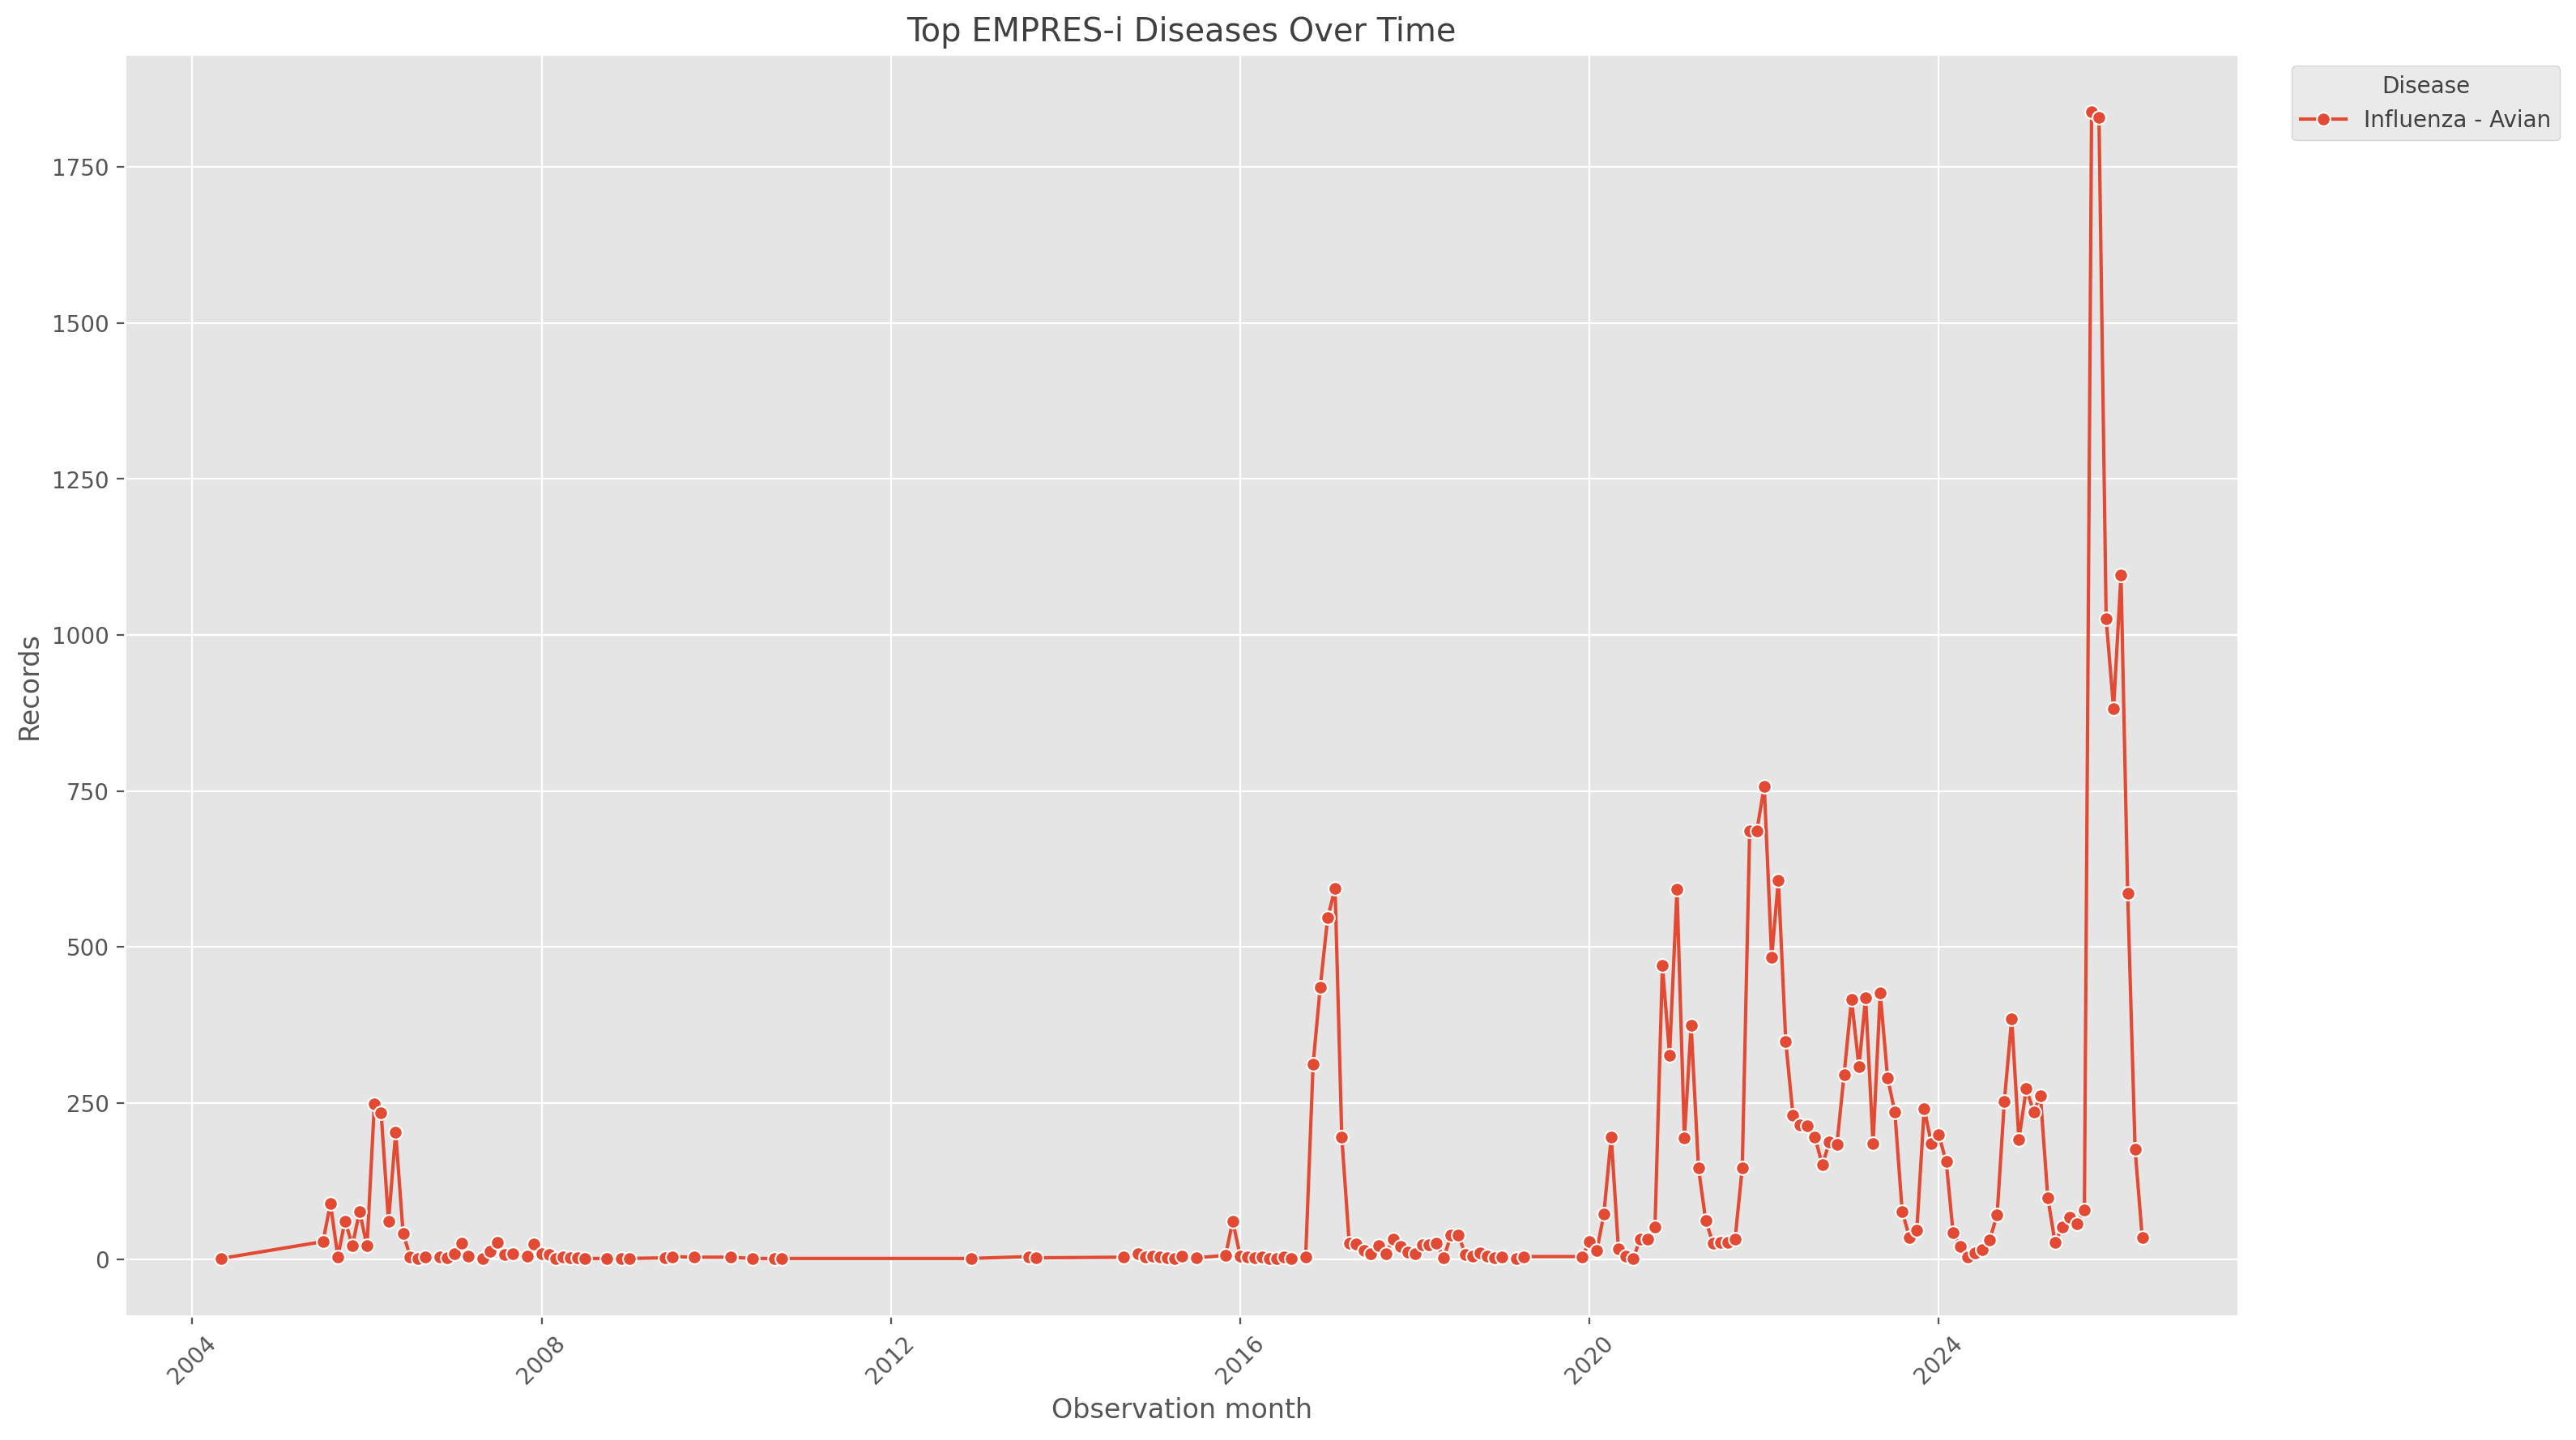

In [8]:
events_by_month_and_disease = monthly_counts_by_category(
    df,
    date_column="Observation.date..dd.mm.yyyy.",
    category_column="Disease",
    top_n=6,
)

sns.lineplot(
    data=events_by_month_and_disease,
    x="month",
    y="records",
    hue="Disease",
    marker="o",
)
plt.title("Top EMPRES-i Diseases Over Time")
plt.xlabel("Observation month")
plt.ylabel("Records")
plt.xticks(rotation=45)
plt.legend(title="Disease", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Delay Analysis


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
report_delay_days,24821.0,20.664034,30.561983,0.0,3.0,6.0,12.0,23.0,46.0,66.0,142.0,733.0


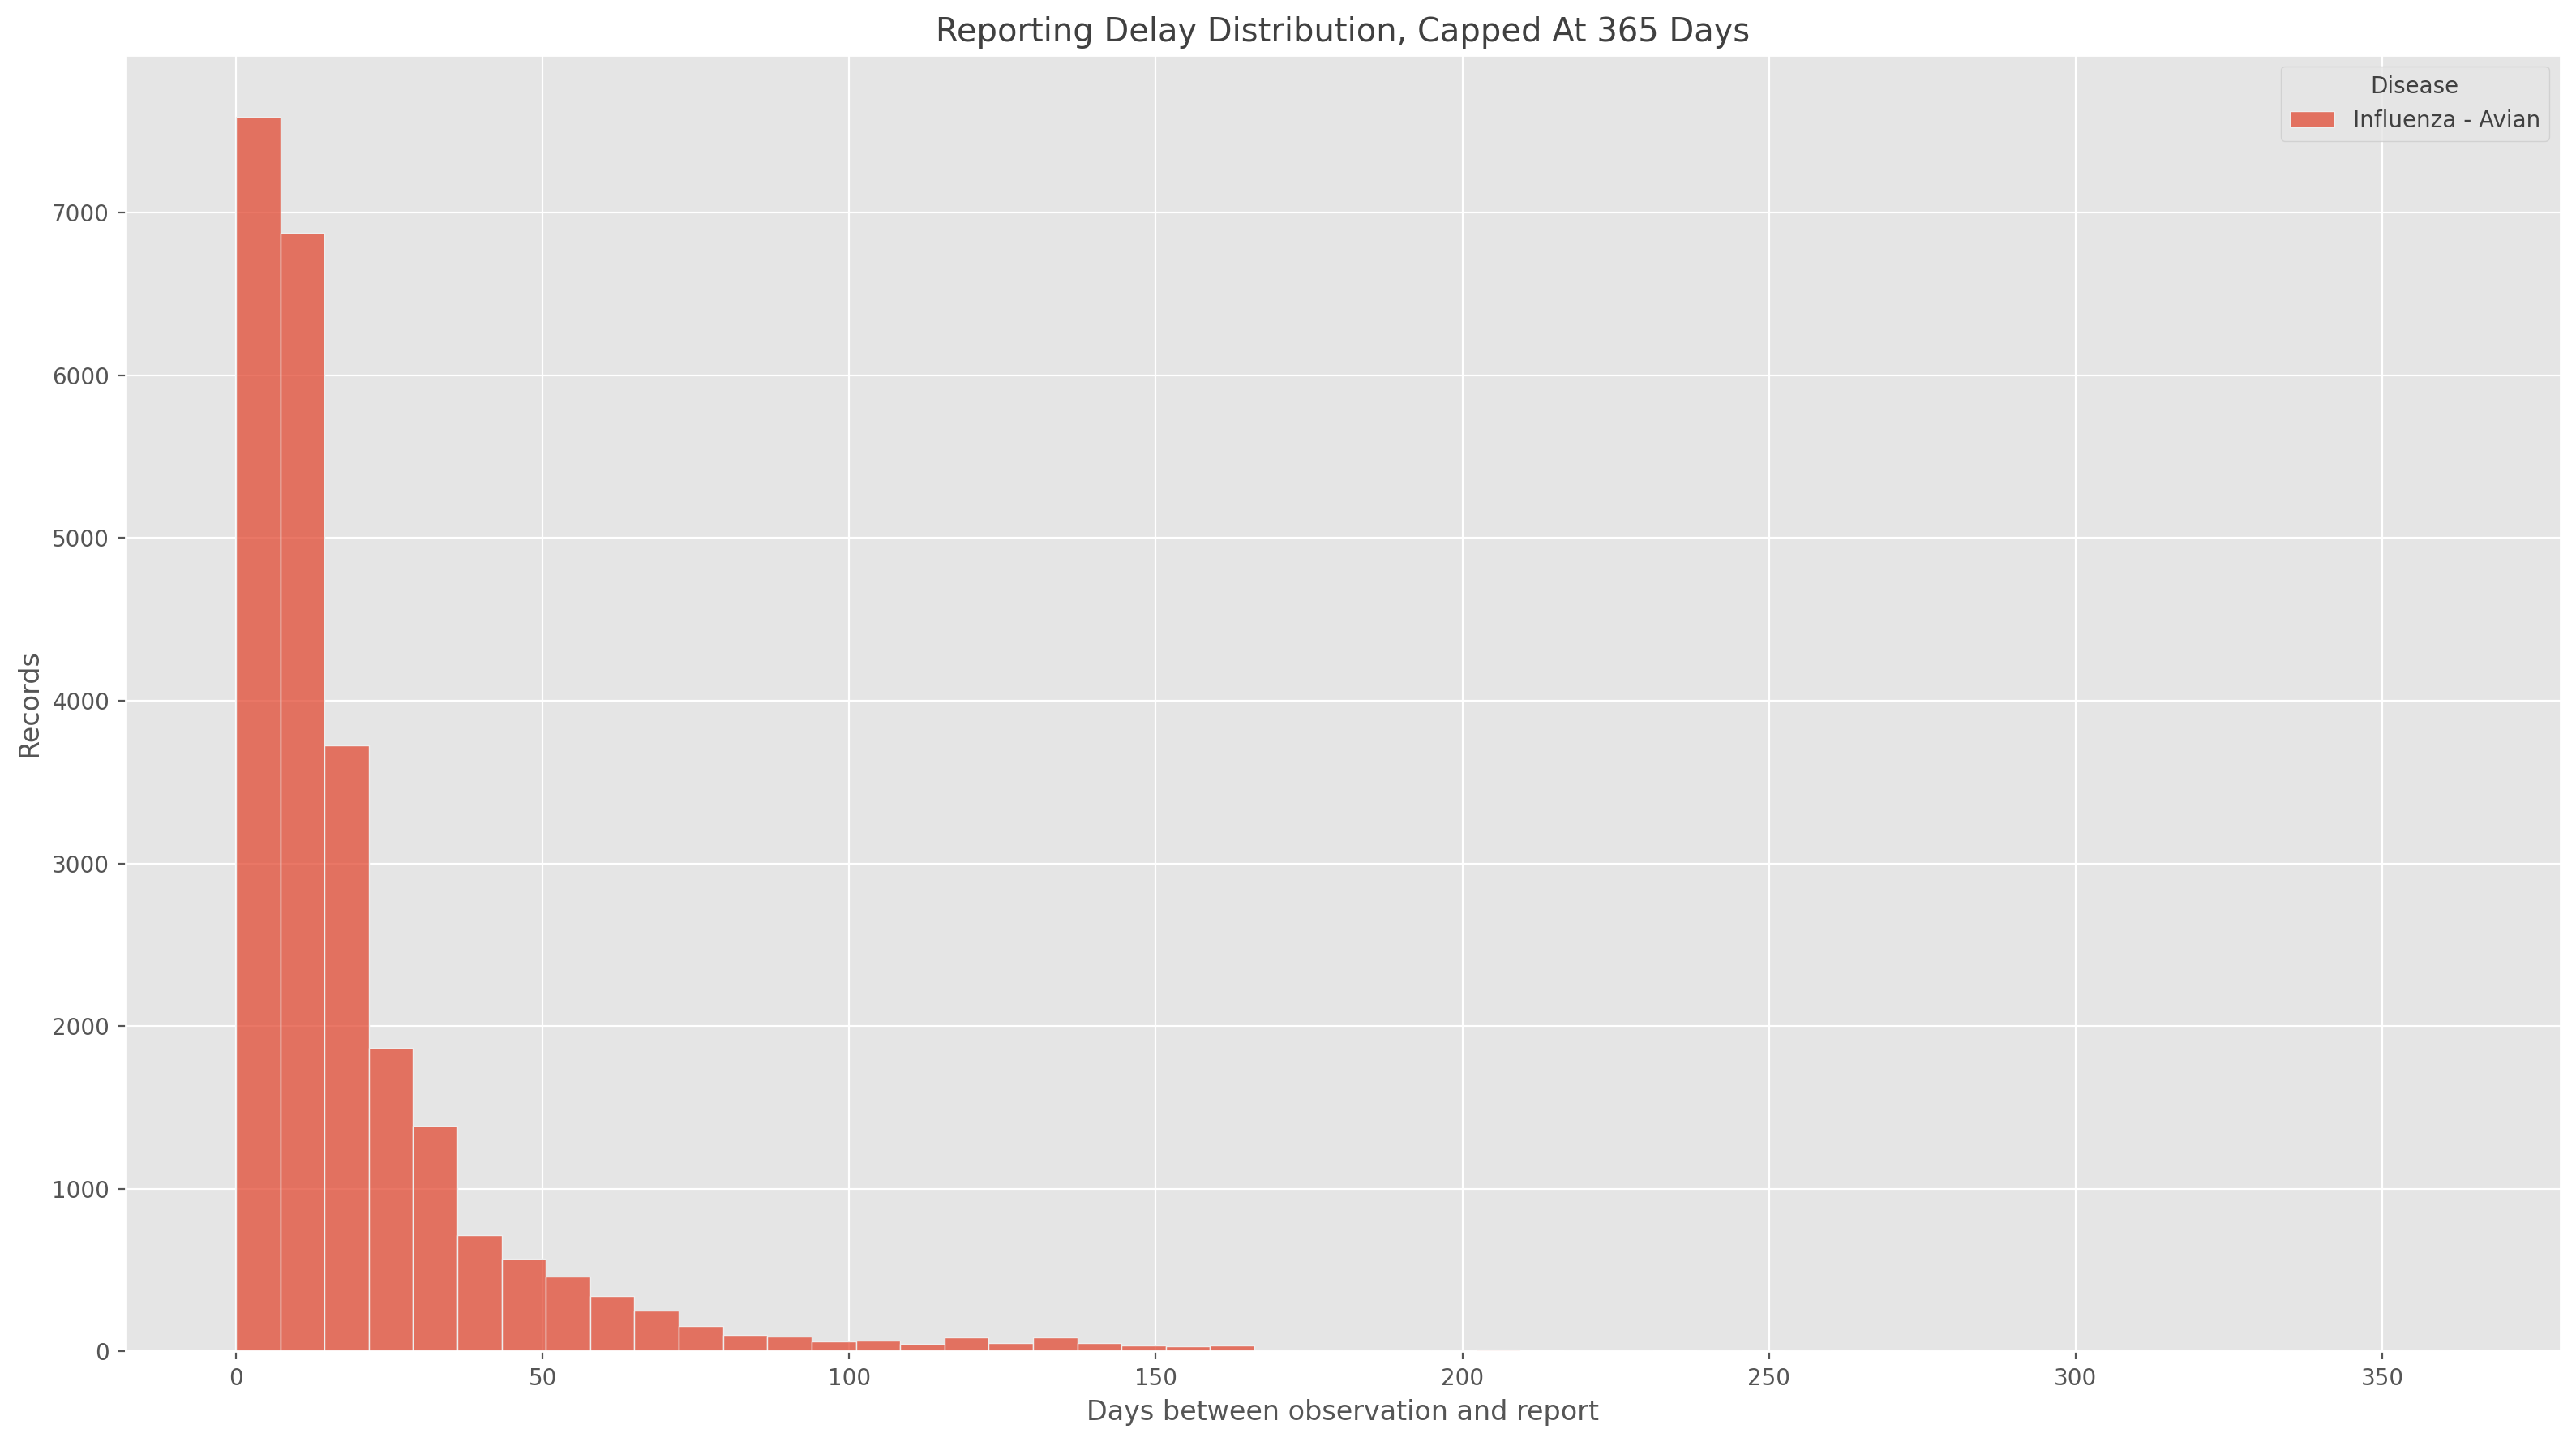

In [9]:
delay_columns = ["report_delay_days"]

display(
    df[delay_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
)

delay_plot_df = df[df["report_delay_days"].between(0, 365, inclusive="both")]
sns.histplot(
    data=delay_plot_df, x="report_delay_days", hue="Disease", bins=50, multiple="stack"
)
plt.title("Reporting Delay Distribution, Capped At 365 Days")
plt.xlabel("Days between observation and report")
plt.ylabel("Records")
plt.tight_layout()

In [10]:
df.loc[
    df["report_delay_days"].notna(),
    [
        "Event.ID",
        "Country",
        "Disease",
        "Serotype",
        "Observation.date..dd.mm.yyyy.",
        "Report.date..dd.mm.yyyy.",
        "report_delay_days",
    ],
].sort_values("report_delay_days", ascending=False).head(20)

,Event.ID,Country,Disease,Serotype,Observation.date..dd.mm.yyyy.,Report.date..dd.mm.yyyy.,report_delay_days
36249,403981-0skat,Poland,Influenza - Avian,H5N1 HPAI,2023-03-30,2025-04-01,733.0
32988,410073-pdowu,Svalbard and Jan Mayen Islands,Influenza - Avian,H5N1 HPAI,2023-07-13,2025-06-27,715.0
32408,410074-kwyfc,Svalbard and Jan Mayen Islands,Influenza - Avian,H5N1 HPAI,2023-07-31,2025-06-27,697.0
47473,410261-32wly,the United Kingdom of Great Britain and Northe...,Influenza - Avian,H5N1 HPAI,2022-01-14,2023-10-26,650.0
85486,129350-s0fvs,Russian Federation,Influenza - Avian,H5N1 HPAI,2007-02-19,2008-10-15,604.0
43608,410262-eiivs,the United Kingdom of Great Britain and Northe...,Influenza - Avian,H5N1 HPAI,2022-05-23,2023-10-26,521.0
50947,410631-2s0yz,the United Kingdom of Great Britain and Northe...,Influenza - Avian,H5N1 HPAI,2021-10-18,2023-02-09,479.0
37487,377074-dq5vb,Netherlands (Kingdom of the),Influenza - Avian,H5N1 HPAI,2023-02-19,2024-04-03,409.0
28617,396755-5duxm,Poland,Influenza - Avian,H5N1 HPAI,2024-01-02,2025-01-21,385.0
43719,354862-lkz5a,Poland,Influenza - Avian,H5N1 HPAI,2022-05-15,2023-05-31,381.0


## Country-Disease Matrix


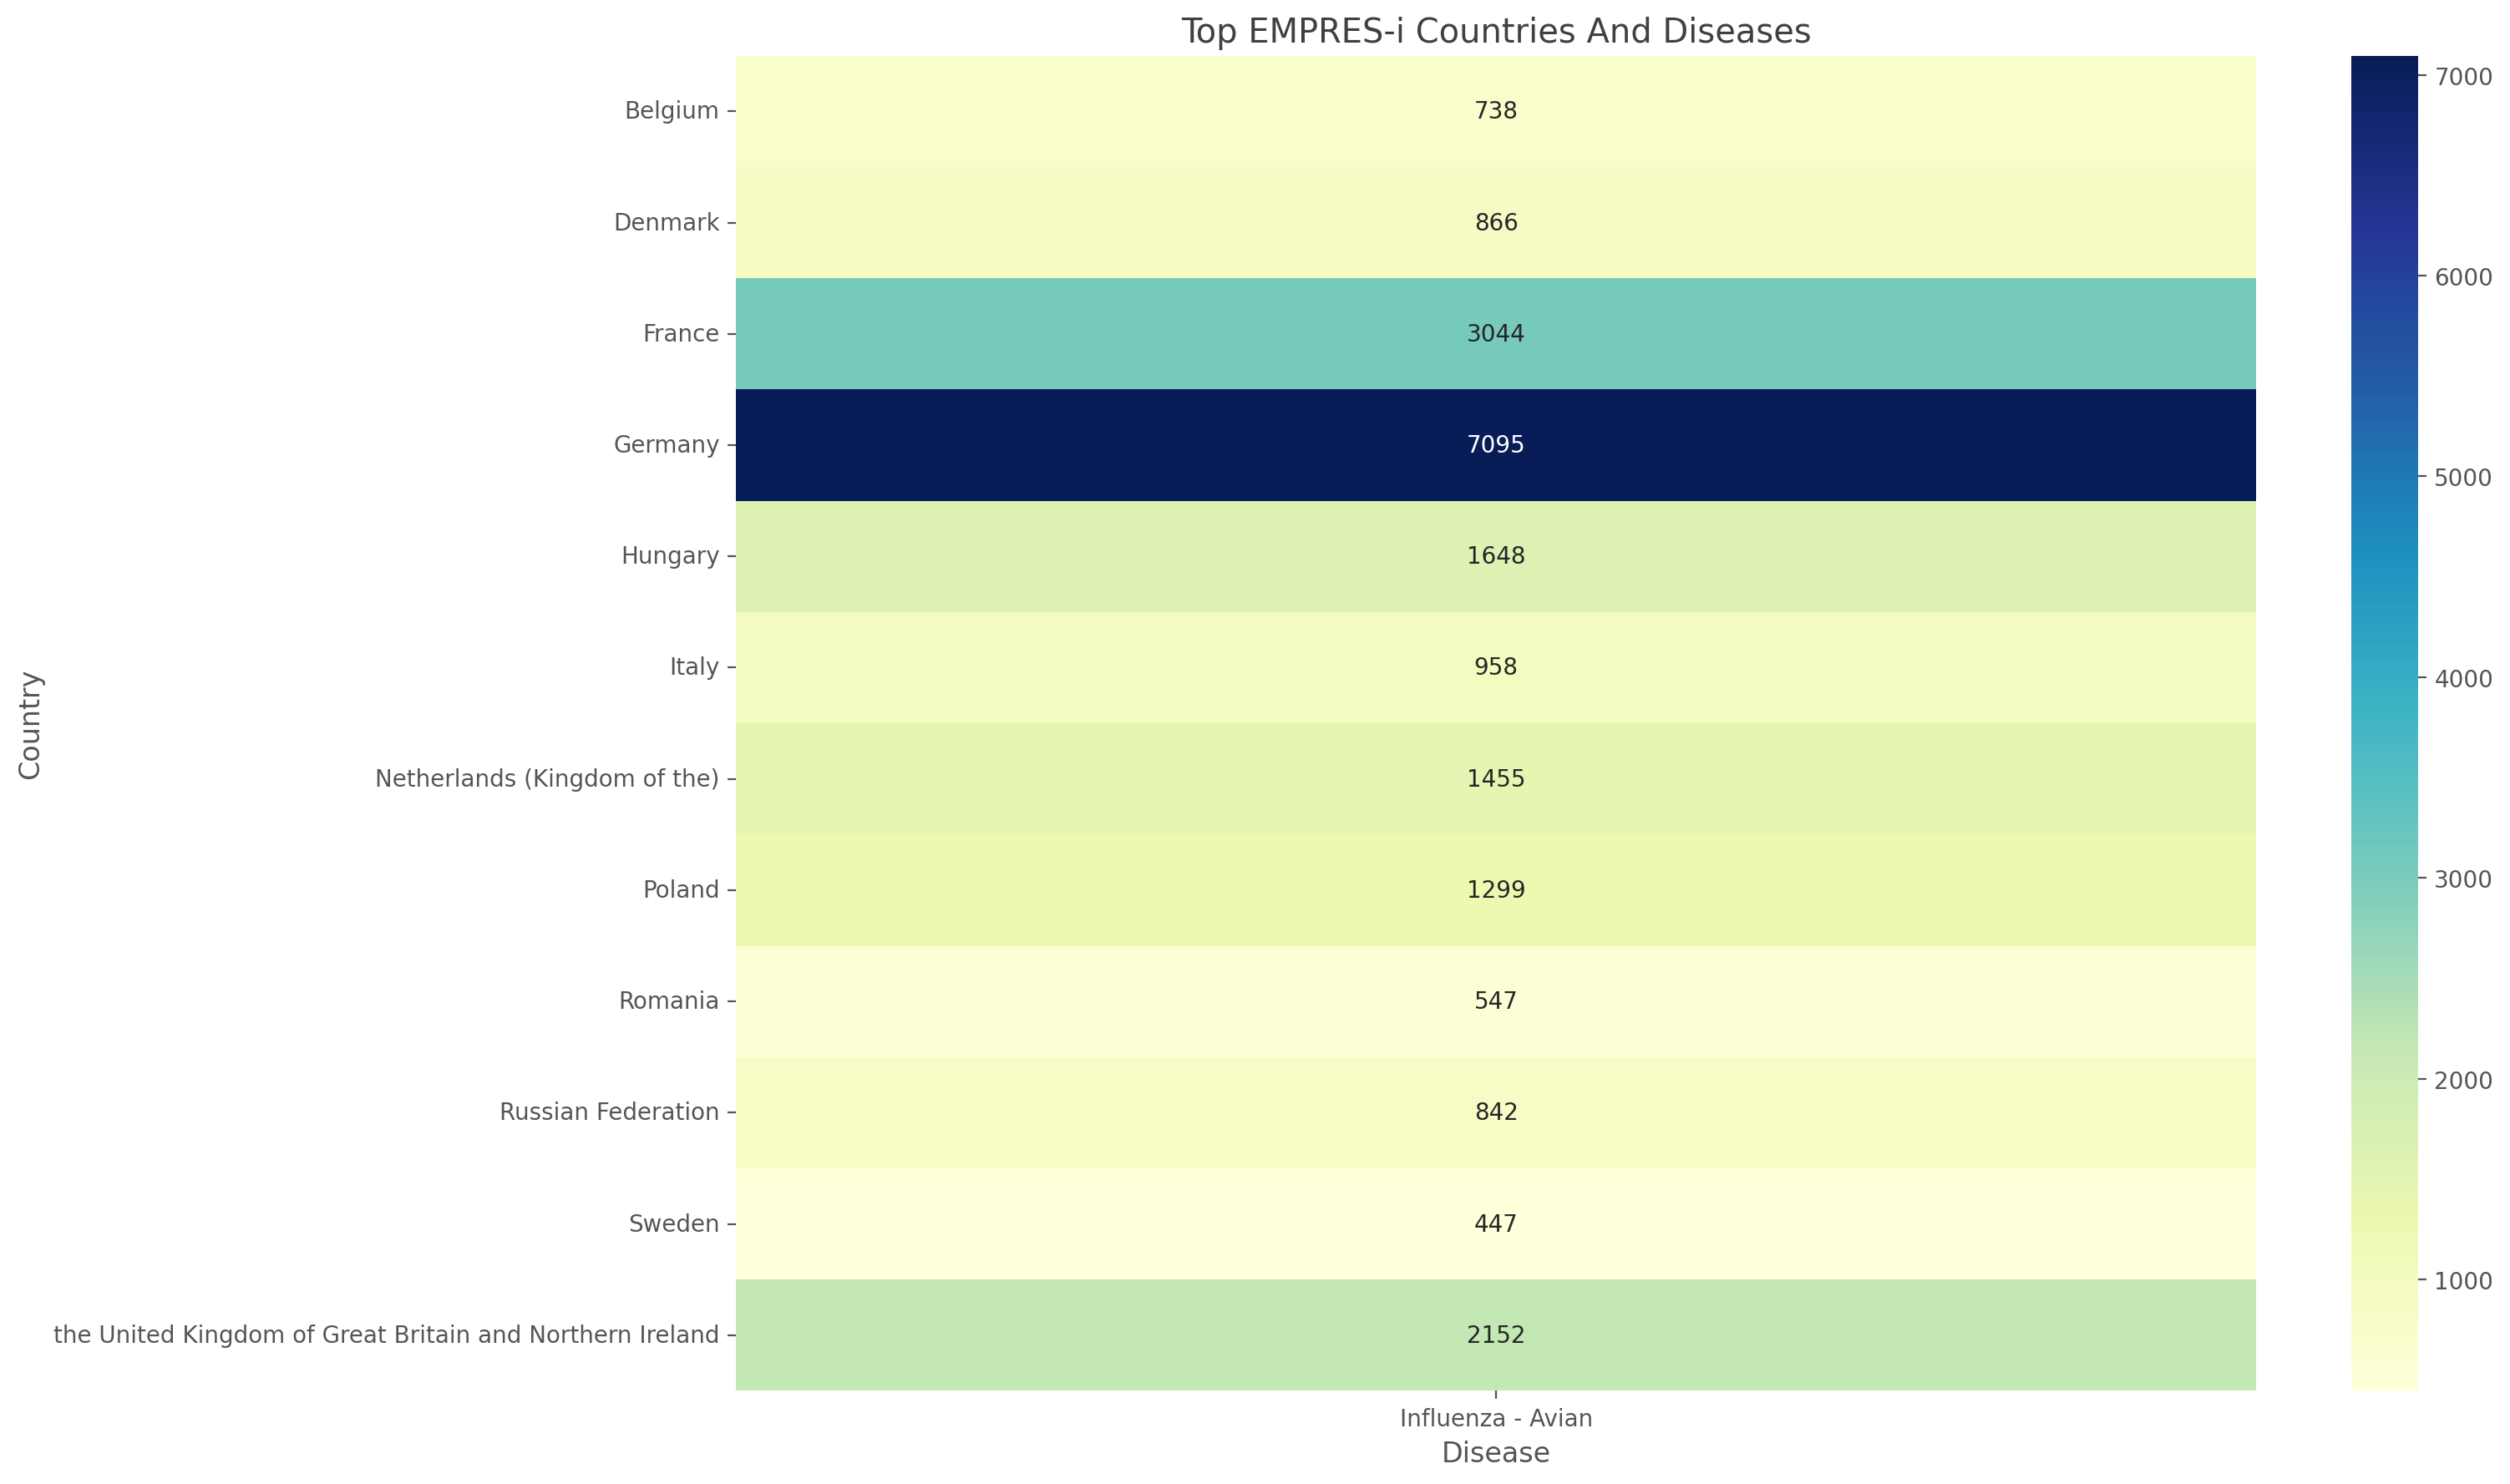

In [11]:
matrix = country_disease_matrix(df, "Country", "Disease")

sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Top EMPRES-i Countries And Diseases")
plt.xlabel("Disease")
plt.ylabel("Country")
plt.tight_layout()

## Geographic Snapshot

Map HPAI event coordinates on a basemap. EMPRES-i has many records, so the plotted layer is sampled for readability while the descriptive statistics still use all geocoded HPAI rows. This cell uses `contextily` basemap tiles when executed; set `BASEMAP_SOURCE` in the setup cell if another provider is preferred.

,Longitude,Latitude
count,24913.000000,24913.000000
mean,10.985217,50.574355
std,12.735576,4.595351
min,-23.804775,32.655446
25%,4.323764,46.882805
50%,9.694602,51.331451
75%,15.748630,53.550646
max,166.010343,78.985426


ConnectTimeout: HTTPSConnectionPool(host='a.basemaps.cartocdn.com', port=443): Max retries exceeded with url: /light_all/2/3/1.png (Caused by ConnectTimeoutError(<HTTPSConnection(host='a.basemaps.cartocdn.com', port=443) at 0x11b7f7c50>, 'Connection to a.basemaps.cartocdn.com timed out. (connect timeout=None)'))

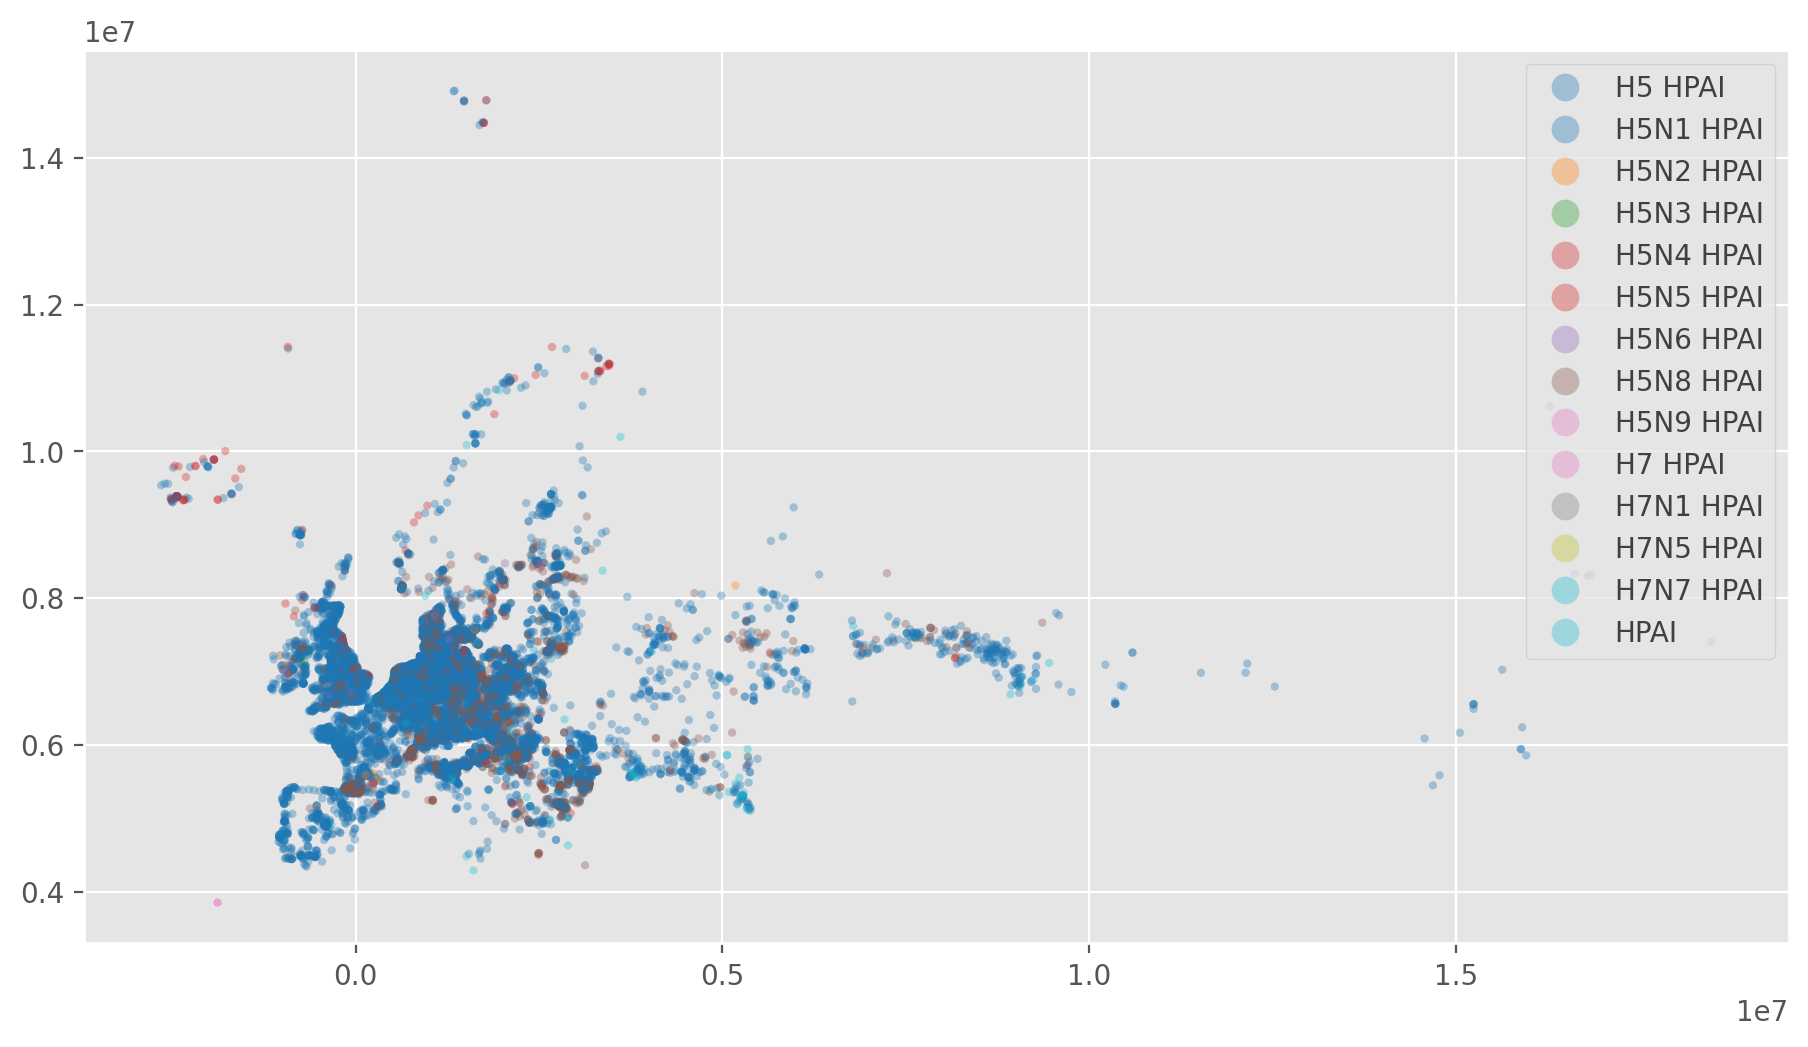

In [12]:
geo_df = df.dropna(subset=['Longitude', 'Latitude']).copy()

display(geo_df[['Longitude', 'Latitude']].describe())

mapped_events = plot_event_map(
    geo_df,
    longitude_column='Longitude',
    latitude_column='Latitude',
    color_column='Serotype',
    title='EMPRES-i HPAI Event Coordinates, Sampled Up To 20,000 Rows',
    sample_n=20_000,
    marker_size=9,
    alpha=0.35,
)

mapped_events[['Country', 'Disease', 'Serotype', 'Latitude', 'Longitude']].head()

## Source-Specific Signals

EMPRES-i includes diagnosis source/status, animal host fields, and human impact fields that are not present in WAHIS or ADIS.


In [ ]:
source_specific = {
    "diagnosis_status_by_disease": pd.crosstab(
        df["Disease"], df["Diagnosis.status"], dropna=False
    ),
    "diagnosis_source_by_disease": pd.crosstab(
        df["Disease"], df["Diagnosis.source"], dropna=False
    ),
    "top_admin1": top_counts(df, "Admin.level.1", 20),
    "top_species": top_counts(df, "Species", 20),
}

display(source_specific["diagnosis_status_by_disease"])
display(source_specific["diagnosis_source_by_disease"])
display(source_specific["top_admin1"])
display(source_specific["top_species"])

In [ ]:
human_impact = df.loc[
    df[["Humans.affected", "Human.deaths"]].notna().any(axis=1),
    [
        "Event.ID",
        "Disease",
        "Serotype",
        "Country",
        "Observation.date..dd.mm.yyyy.",
        "Humans.affected",
        "Human.deaths",
    ],
].sort_values(["Humans.affected", "Human.deaths"], ascending=False)

human_impact.head(25)

## Quick Filters

Set any filter to a string value, or leave it as `None` to ignore that filter.


In [ ]:
country_filter = None
disease_filter = None
serotype_filter = None
diagnosis_status_filter = None

filtered = df.copy()
if country_filter:
    filtered = filtered[filtered["Country"].eq(country_filter)]
if disease_filter:
    filtered = filtered[filtered["Disease"].eq(disease_filter)]
if serotype_filter:
    filtered = filtered[filtered["Serotype"].eq(serotype_filter)]
if diagnosis_status_filter:
    filtered = filtered[filtered["Diagnosis.status"].eq(diagnosis_status_filter)]

filtered.sort_values("Report.date..dd.mm.yyyy.", ascending=False).head(50)